# Basic comparsion of naive and fast convolution

In [62]:
import numpy as np
import sympy as sy
from scipy import signal
from scipy import datasets
from matplotlib import pyplot as plt

In [63]:
from fast_convolution.naive import naive_convolve
from fast_convolution import fast 
from fast_convolution.utils import plot_pdf, symmetrical_cyclic_convolution

In [64]:
from sympy import init_printing
init_printing(use_latex='png', forecolor='White', backcolor='Black')

Lets do a really basic test to compare naive with fast convolution
The input feature will be a simple 5x5 matrix and the output will be a 3x3 matrix

In [65]:
feature = np.arange(8*8).reshape(8, 8)
feature

array([[ 0,  1,  2,  3,  4,  5,  6,  7],
       [ 8,  9, 10, 11, 12, 13, 14, 15],
       [16, 17, 18, 19, 20, 21, 22, 23],
       [24, 25, 26, 27, 28, 29, 30, 31],
       [32, 33, 34, 35, 36, 37, 38, 39],
       [40, 41, 42, 43, 44, 45, 46, 47],
       [48, 49, 50, 51, 52, 53, 54, 55],
       [56, 57, 58, 59, 60, 61, 62, 63]])

In [66]:
weight = np.array([
    [ 1, 0, 1],
    [ 2, 1, 2],
    [ 1, 2, 1],
])
weight

array([[1, 0, 1],
       [2, 1, 2],
       [1, 2, 1]])

In [67]:
np.fliplr(weight)

array([[1, 0, 1],
       [2, 1, 2],
       [1, 2, 1]])

Convolution with no paddin and stride 1
Using convolve2d from scipy, our gold method, it's necessary to reverse the weights to get same result of naive and fast convolution

In [68]:
weight_reversed = weight[::-1, ::-1]
weight_reversed

array([[1, 2, 1],
       [2, 1, 2],
       [1, 0, 1]])

In [69]:
output_default = signal.convolve2d(feature, weight_reversed, mode='valid')
output_default

array([[115, 126, 137, 148, 159, 170],
       [203, 214, 225, 236, 247, 258],
       [291, 302, 313, 324, 335, 346],
       [379, 390, 401, 412, 423, 434],
       [467, 478, 489, 500, 511, 522],
       [555, 566, 577, 588, 599, 610]])

Running naive convolution
9 multiplications and 8 aditions per output scalar

In [70]:
output_naive = naive_convolve(feature, weight)
output_naive

array([[115, 126, 137, 148, 159, 170],
       [203, 214, 225, 236, 247, 258],
       [291, 302, 313, 324, 335, 346],
       [379, 390, 401, 412, 423, 434],
       [467, 478, 489, 500, 511, 522],
       [555, 566, 577, 588, 599, 610]])

In [71]:
np.all(output_default == output_naive)

True

In [72]:
kernel = weight
data = feature

# To simplify things
k = kernel.shape[0]
new_shape = (data.shape[0] - 2, data.shape[1] - 2)
# 2D array of zeros
output = np.zeros(shape=new_shape, dtype=int)

# Iterate over the rows
for i in range(data.shape[0] - k + 1):
    # Iterate over the columns
    for j in range(data.shape[1] - k + 1):
        # img[i, j] = individual pixel value
        # Get the current matrix
        # tmp = data[i:i + k, j:j + k]
        # Apply the convolution - element-wise multiplication and summation of the result
        # Store the result to i-th row and j-th column of our convolved_img array
        # 9 multiplications, 8 aditions per output
        # Iterate over the rows
        for ki in range(k):
            # Iterate over the columns
            for kj in range(k):
                # output[i, j] = output[i, j] + tmp[ki, kj] * kernel[ki, kj]
                output[i, j] = output[i, j] +  data[i + ki, j + kj] * kernel[ki, kj]




In [73]:
kernel = weight.reshape(-1)
data = feature.reshape(-1)

# To simplify things
k = weight.shape[0]
new_shape = ((feature.shape[0] - 2) * (feature.shape[1] - 2))
# 2D array of zeros
output = np.zeros(shape=new_shape, dtype=int)

# Iterate over the rows
for i in range(feature.shape[0] - k + 1):
    # Iterate over the columns
    for j in range(feature.shape[1] - k + 1):
        # img[i, j] = individual pixel value
        # Get the current matrix
        # tmp = data[i:i + k, j:j + k]
        # Apply the convolution - element-wise multiplication and summation of the result
        # Store the result to i-th row and j-th column of our convolved_img array
        # 9 multiplications, 8 aditions per output
        # Iterate over the rows
        for ki in range(k):
            # Iterate over the columns
            for kj in range(k):
                # output[i + j] = output[i + j] + tmp[ki + kj] * kernel[ki + kj]
                output[i*6 + j] = output[i*6 + j] + data[(i + ki)*feature.shape[0]+ j + kj] * kernel[ki*weight.shape[0] + kj]




In [74]:
np.all(output_default == output.reshape(6,6))

True

In [75]:
d_size = 2
g_size = 3

points = [0, -1, 1, np.inf]

c1, q1, b1, a1 = fast.toom_cook(d_size, g_size, points)
c2, q2, b2, a2 = fast.toom_cook(d_size, g_size, points)

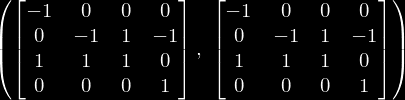

In [76]:
c1, c2

In [77]:
bg = fast.g_to_bg2d(q1, b1, q2, b2, kernel)
#bg = fast.g_to_bg(q, b, kernel[0])
bg

ShapeError: Matrix size mismatch: (4, 3) * (9, 1).

In [78]:
data_fast = data[:4, :4]
data_fast

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

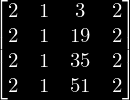

In [79]:
data0 = sy.Matrix(data_fast) * c2
data0

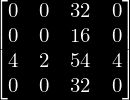

In [80]:
data1 = c1.T * data0
data1

In [81]:
m1 = data_fast
m2 = c2
m3 = np.zeros((4, 4), dtype=int)

for r in range(m1.shape[0]):
    for c in range(m2.shape[1]):
        for t in range(m1.shape[1]):
            m3[r, c] = m3[r, c] + m1[r, t] * m2[t, c]

m3

array([[ 2,  1,  3,  2],
       [ 2,  1, 19,  2],
       [ 2,  1, 35,  2],
       [ 2,  1, 51,  2]])

In [97]:
m1 = data_fast.reshape(-1)
m2 = np.array(c2).reshape(-1)

row1 = data_fast.shape[0]
col1 = data_fast.shape[1]

row2 = c2.shape[0]
col2 = c2.shape[1]

row3 = row1
col3 = col2

m3 = np.zeros((row1 * col2), dtype=int)

for r in range(row1):
    for c in range(col2):
        for t in range(col1):
            m3[r*col2 + c] = m3[r * col3 + c] + m1[r * col1 + t] * m2[t * col2 + c]

m3.reshape(4,4)

array([[ 2,  1,  3,  2],
       [ 2,  1, 19,  2],
       [ 2,  1, 35,  2],
       [ 2,  1, 51,  2]])

In [91]:
np.array(c2)

array([[-1, 0, 0, 0],
       [0, -1, 1, -1],
       [1, 1, 1, 0],
       [0, 0, 0, 1]], dtype=object)

In [94]:
data_fast

array([[ 0,  1,  2,  3],
       [ 8,  9, 10, 11],
       [16, 17, 18, 19],
       [24, 25, 26, 27]])

In [92]:
row1, col1, row2, col2, row3, col3